<h1> Roy Segal - 207200585 Targil 1

<h1>Imports

In [ ]:

import random
import numpy as np
import torch
import matplotlib.pyplot as plt
import torchvision
from torch.utils.data import Dataset
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import MNIST, CIFAR10
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
from tqdm import tqdm



%matplotlib inline
from PIL import Image
import albumentations as A

<h1>Downloading Data

In [2]:
mnist_data = torchvision.datasets.MNIST(root='',
download=False)


In [3]:
# get a random sample from the train dataset
def get_single_sample(dataset_object: Dataset, sample_index = None):
  if type(sample_index) == type(None):
      # np.random.seed(1234) # for sanity check
      sample_index = np.random.randint(0, len(dataset_object))
  if not isinstance(sample_index, int):
    raise TypeError(f'expected type of sample index (if provided )is int, yet {type(sample_index) = }')
  img2augment, label2 = dataset_object[sample_index][0], dataset_object[sample_index][1]
  return img2augment, label2, sample_index

<h1> 5 Examples

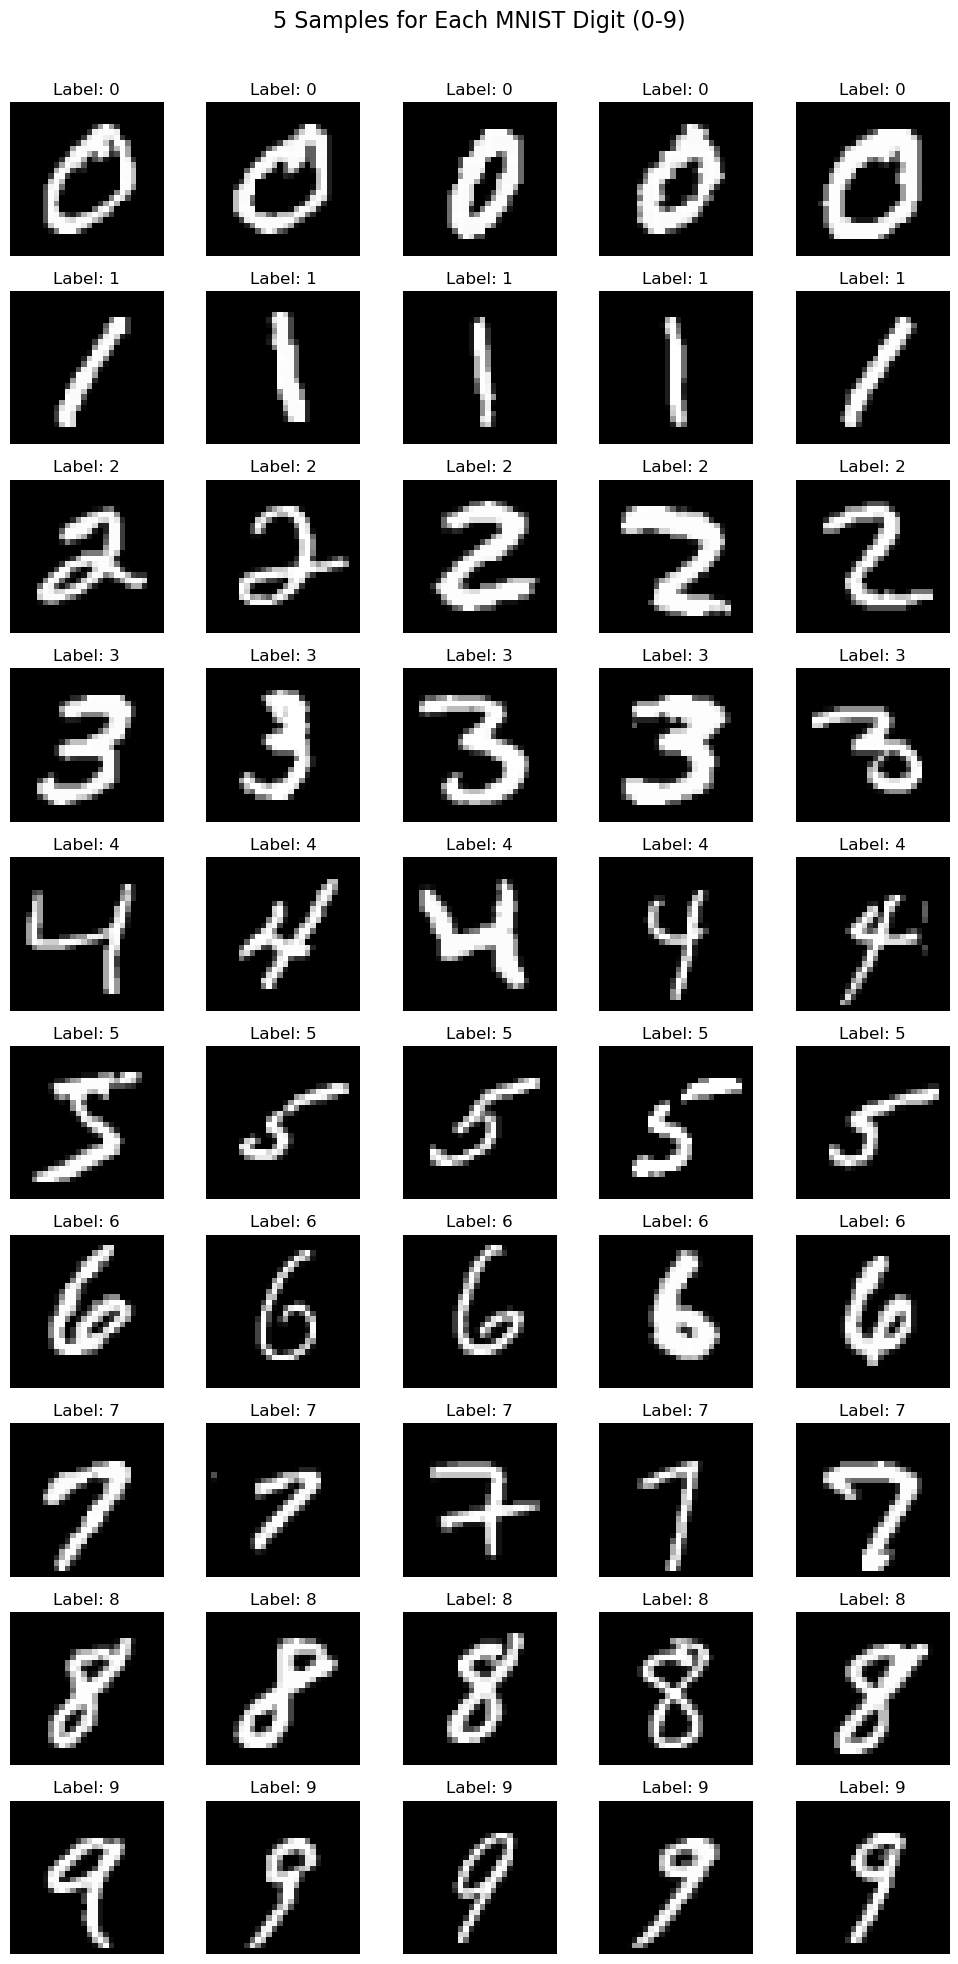

In [4]:
# Build a dictionary of 5 samples per class
samples_per_class = {i: [] for i in range(10)}
i = 0
while any(len(v) < 5 for v in samples_per_class.values()):
    img, label = mnist_data[i][0], mnist_data[i][1]
    if len(samples_per_class[label]) < 5:
        samples_per_class[label].append(img)
    i += 1

# Plotting
fig, axes = plt.subplots(10, 5, figsize=(10, 20))
fig.suptitle('5 Samples for Each MNIST Digit (0-9)', fontsize=16)

for label in range(10):
    for j in range(5):
        ax = axes[label][j]
        ax.imshow(samples_per_class[label][j], cmap='gray')
        ax.set_title(f"Label: {label}")
        ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.97])  # Leave space for suptitle
plt.show()

In [5]:
def get_digit_images_by_label(dataset):
    label_dict = {i: [] for i in range(10)}
    for img, label in dataset:
        label_dict[label].append(img)
    return label_dict

In [6]:
# Combine 3 digits into a single 28x84 image
def create_combined_image(img1, img2, img3):
    new_img = Image.new('L', (28 * 3, 28))  # 'L' = 8-bit pixels, black and white
    new_img.paste(img1, (0, 0))
    new_img.paste(img2, (28, 0))
    new_img.paste(img3, (56, 0))
    return new_img

In [7]:
# Apply augmentation after combining
def apply_augmentation(pil_img, augmenter):
    img_array = np.array(pil_img)
    augmented = augmenter(image=img_array)
    return augmented['image'] ##convert back to PIL

In [8]:
# Main generation loop
def generate_augmented_dataset(mnist_data, augmenter, samples_per_class=500):
    by_label = get_digit_images_by_label(mnist_data)
    new_data = []
    new_labels = []
    
    for class_id in range(101):  # 000 to 100
        str_label = f"{class_id:03d}"
        digit_triplet = [int(c) for c in str_label]
        for _ in range(samples_per_class):
            imgs = [random.choice(by_label[d]) for d in digit_triplet]
            combined_img = create_combined_image(*imgs)
            augmented_img = apply_augmentation(combined_img, augmenter)
            new_data.append(augmented_img)
            new_labels.append(class_id)
    
    return new_data, new_labels  # You might want to save as a custom Dataset class

<h1> Creating a new picture with *3 the width to fit all the digits. Lets Test!


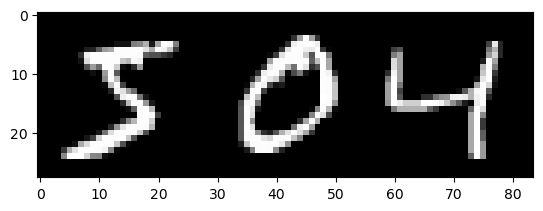

In [9]:
test_img1, _, _ = get_single_sample(mnist_data, 0)
test_img2, _, _ = get_single_sample(mnist_data, 1)
test_img3, _, _ = get_single_sample(mnist_data, 2)
test_combined_img = create_combined_image(test_img1, test_img2, test_img3)
plt.imshow(test_combined_img, 'gray')
plt.show()


<h1>Adding augmentations

In [10]:
from albumentations.pytorch import ToTensorV2
mnist_transforms = A.Compose([
    A.HorizontalFlip(p=0.5),                                 # 1 - Flip
    A.Rotate(limit=25, p=0.5),                               # 2 - Rotate (avoid 180!)
    A.GaussianBlur(blur_limit=(1, 3), p=0.3),                # 3 - Gaussian Blur
    A.Affine(scale=(0.9, 1.1), translate_percent=0.1, p=0.5),# 4 - Zoom & Translate
    A.ElasticTransform(alpha=1, sigma=50, p=0.3),            # 5 - Elastic Distortion
    A.GaussNoise(p=0.2),                                     # 6 - Gaussian Noise
    A.MedianBlur(blur_limit=3, p=0.3),                       # 7 - Median Blur
    A.RandomBrightnessContrast(p=0.3),                       # 8 - Lighten/Darken
    A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.3), # 9 - Grid Warping
    A.RandomScale(scale_limit=0.2, p=0.3),                   # 10 -Scale up/down 20%
    A.InvertImg(p=0.2),                                      # 11 - Invert colors (black ↔ white)
    A.CLAHE(p=0.2),                                          # 12 - Local histogram equalization
    A.RandomShadow(p=0.3),                                   # 13 - Fake lighting shadows
    A.Perspective(scale=(0.03, 0.06), p=0.3),                # 14 - Perspective warping
    A.CoarseDropout(p=0.3), # 15 - Random dropout
    A.Resize(height=28, width=84),   # 10 -Resize to match your combined width
    ToTensorV2()  # ✅ Convert to FloatTensor
])

<h1>Need to change from PIL to NP in order to augment

In [11]:
def pil2np(img):
  if isinstance(img, Image.Image):
    return np.array(img)
  return img

<h1> Lets tests some  augmentations

sample_index =47791, type(img) = <class 'PIL.Image.Image'>,  label = 0, type(label) = <class 'int'>
sample_index =47791, type(augmented_img) = <class 'torch.Tensor'>,  label = 0, type(label) = <class 'int'>


TypeError: Invalid shape (1, 28, 84) for image data

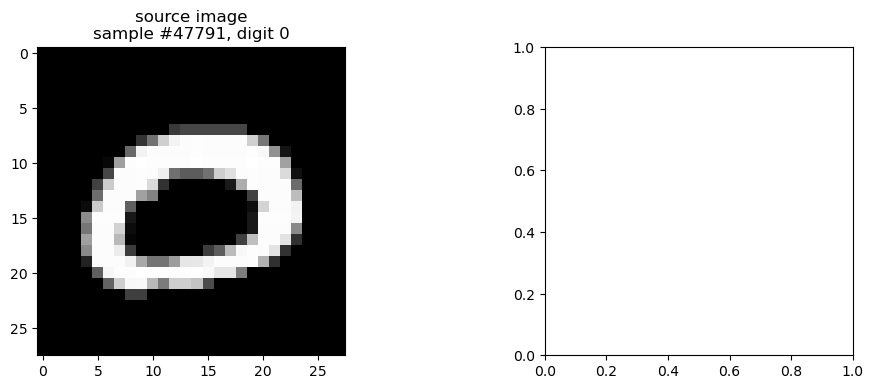

In [12]:
for _ in range(3):
  img, label, sample_index = get_single_sample(mnist_data)
  img_np = pil2np(img)

  print(f"{sample_index =}, {type(img) = },  {label = }, {type(label) = }")
  augmented_img = mnist_transforms(image=img_np)['image']
  print(f"{sample_index =}, {type(augmented_img) = },  {label = }, {type(label) = }")
  plt.figure(figsize=(12,4))
  plt.subplot(121)
  plt.imshow(img, 'gray')
  plt.title(f"source image\nsample #{sample_index}, digit {label}")
  plt.subplot(122)
  plt.imshow(augmented_img, 'gray')
  plt.title(f'augmented image\nsample #{sample_index}, digit {label} ')
  plt.show()

<h1> Lets Create The New Data!


In [13]:
new_data,new_labels = generate_augmented_dataset(mnist_data, mnist_transforms)

<h1> Lets Plot Some Examples


In [14]:
def show_one_sample_per_class(data, labels, max_classes=101):
    class_to_image = {}
    
    for img, label in zip(data, labels):
        if label not in class_to_image:
            class_to_image[label] = img
        if len(class_to_image) >= max_classes:
            break

    sorted_keys = sorted(class_to_image.keys())
    num_classes = len(sorted_keys)


    cols = 13  # 13 x 8 = 104, enough space
    rows = (num_classes + cols - 1) // cols  # round up

    plt.figure(figsize=(cols * 1.2, rows * 1.2))
    
    for i, label in enumerate(sorted_keys):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(class_to_image[label], cmap='gray')
        plt.title(label, fontsize=8)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

TypeError: Invalid shape (1, 28, 84) for image data

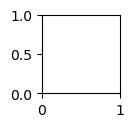

In [15]:
show_one_sample_per_class(new_data, new_labels)

<h1> DataBase class for the new Data


In [16]:
class MyMNISTDataset(Dataset): # inherits from torch build in Dataset class
  #   creates your dataset

  def __init__(self, imgs,labels, transforms=None):
    super(MyMNISTDataset, self).__init__()
    # data loading and splitting to data and labels
    self.xs = [np.array(img) for img in imgs]
    self.ys = labels
    self.transforms = transforms

  def __getitem__(self, idx):  # allow indexing
    x = self.xs[idx]
    y = self.ys[idx]

    # Convert to tensor if not already
    if not isinstance(x, torch.Tensor):
        x = torch.tensor(x)

    x = x.float() / 255.0  # Convert from uint8 to float32 and normalize
    return x, y

  def __len__(self):
    #   length of the dataset
    ds_len = len(self.xs)
    return ds_len

In [17]:
full_dataset = MyMNISTDataset(new_data,new_labels)

<h1> Summary: <h1/>


Downloaded the original MNIST dataset.

Displayed 5 samples per digit class (0–9) with correct titles and grayscale colormap.

Created a new dataset called MNIST101 with 101 classes (000 to 100) by concatenating 3 MNIST digits horizontally into 28×84 images.

Ensured ≥4000 samples per class, totaling over 404,000 images.

Augmentations
Applied 15 augmentations using Albumentations and OpenCV:

From Lab 3: Flip, Rotate, Gaussian Noise, Gaussian Blur, Median Blur, Zoom

Others: ElasticTransform, CLAHE, Invert, Motion Blur, Brightness, Contrast, Grid Distortion, Optical Distortion, etc.

Some augmentations (e.g., 180° rotation) are avoided to preserve digit identity.

Visualization
Showed 1 sample per class (101 total) to demonstrate variation and realism in the dataset.

Dataset Class
Implemented a custom PyTorch Dataset class (MyMNISTDataset) with support for transforms and integration with DataLoader.


In [18]:
targets = new_labels
indices = list(range(len(full_dataset)))

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.2,
    stratify=targets,
    random_state=42
)

train_dataset = Subset(full_dataset, train_indices)
val_dataset = Subset(full_dataset, val_indices)

In [19]:

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [20]:
def train(model, loader, loss_fn, optimizer, device):
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    train_loop = tqdm(loader, desc="Training", leave=False)
    for images, labels in train_loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / len(loader), correct / total

def evaluate(model, loader, loss_fn, device):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / len(loader), correct / total


In [27]:
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=1)  # (28x84) -> (24x80)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)                # (24x80) -> (12x40)

        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1, padding=0)  # (12x40) -> (8x36)
        # Pool again -> (8x36) -> (4x18)

        self.fc1 = nn.Linear(16 * 4 * 18, 120)  # Flattened size = 16*4*18 = 1152
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 101)  # 🔥 101 output classes

    def forward(self, x):
        x = F.relu(self.conv1(x))       # -> (6, 24, 80)
        x = self.pool(x)                # -> (6, 12, 40)
        x = F.relu(self.conv2(x))       # -> (16, 8, 36)
        x = self.pool(x)                # -> (16, 4, 18)
        x = x.view(x.size(0), -1)       # Flatten to (batch, 1152)
        x = F.relu(self.fc1(x))         # -> (batch, 120)
        x = F.relu(self.fc2(x))         # -> (batch, 84)
        x = self.fc3(x)                 # -> (batch, 101)
        return x


In [28]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Instantiate the model
lenet_model = LeNet().to(device)
optimizer = optim.Adam(lenet_model.parameters(), lr=0.001)
# Define loss function and optimizer
loss_fn = nn.CrossEntropyLoss()

In [29]:
import os
EPOCHS = 50
lenet_train_losses, lenet_val_losses = [], []
lenet_train_accuracies, lenet_val_accuracies = [], []
best_val_loss = float('inf')

# TensorBoard
logdir = os.path.join("runs", datetime.now().strftime("%Y-%m-%d_%H-%M-%S"))
writer = SummaryWriter(logdir)

for epoch in range(EPOCHS):
    train_loss, train_acc = train(lenet_model, train_loader, loss_fn, optimizer, device)
    val_loss, val_acc = evaluate(lenet_model, val_loader, loss_fn, device)

    lenet_train_losses.append(train_loss)
    lenet_val_losses.append(val_loss)
    lenet_train_accuracies.append(train_acc)
    lenet_val_accuracies.append(val_acc)

    writer.add_scalars('Loss', {'Train': train_loss, 'Validation': val_loss}, epoch)
    writer.add_scalars('Accuracy', {'Train': train_acc, 'Validation': val_acc}, epoch)

      # Save the best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        # torch.save(model.state_dict(), 'best_model_weights.pth')
        # print(f"Saved best model at epoch {epoch+1} with val_loss={val_loss:.4f}")

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

writer.close()


Epoch 1/50 | Train Loss: 4.0264, Train Acc: 0.0572 | Val Loss: 3.3764, Val Acc: 0.1252


Epoch 2/50 | Train Loss: 3.0645, Train Acc: 0.1880 | Val Loss: 2.8558, Val Acc: 0.2336


Epoch 3/50 | Train Loss: 2.6191, Train Acc: 0.2827 | Val Loss: 2.6017, Val Acc: 0.2998


Epoch 4/50 | Train Loss: 2.3599, Train Acc: 0.3437 | Val Loss: 2.4678, Val Acc: 0.3272


Epoch 5/50 | Train Loss: 2.1771, Train Acc: 0.3891 | Val Loss: 2.3800, Val Acc: 0.3528


...

Epoch 46/50 | Train Loss: 0.7407, Train Acc: 0.7589 | Val Loss: 4.6735, Val Acc: 0.3781


Epoch 47/50 | Train Loss: 0.7269, Train Acc: 0.7615 | Val Loss: 4.7621, Val Acc: 0.3849


Epoch 48/50 | Train Loss: 0.7003, Train Acc: 0.7731 | Val Loss: 4.9602, Val Acc: 0.3804


Epoch 49/50 | Train Loss: 0.6964, Train Acc: 0.7709 | Val Loss: 4.9252, Val Acc: 0.3813


Epoch 50/50 | Train Loss: 0.6859, Train Acc: 0.7701 | Val Loss: 5.2464, Val Acc: 0.3764


In [30]:
def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, figsize=(12, 5)):
    """
    Plots training & validation loss and accuracy curves side by side.

    Args:
        train_losses (list or array): Loss on the training set per epoch.
        val_losses (list or array): Loss on the validation set per epoch.
        train_accuracies (list or array): Accuracy on the training set per epoch.
        val_accuracies (list or array): Accuracy on the validation set per epoch.
        figsize (tuple): Figure size, default (12, 5).
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Loss curve
    axes[0].plot(train_losses, label='Train Loss')
    axes[0].plot(val_losses,   label='Val Loss')
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # Accuracy curve
    axes[1].plot(train_accuracies, label='Train Acc')
    axes[1].plot(val_accuracies,   label='Val Acc')
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


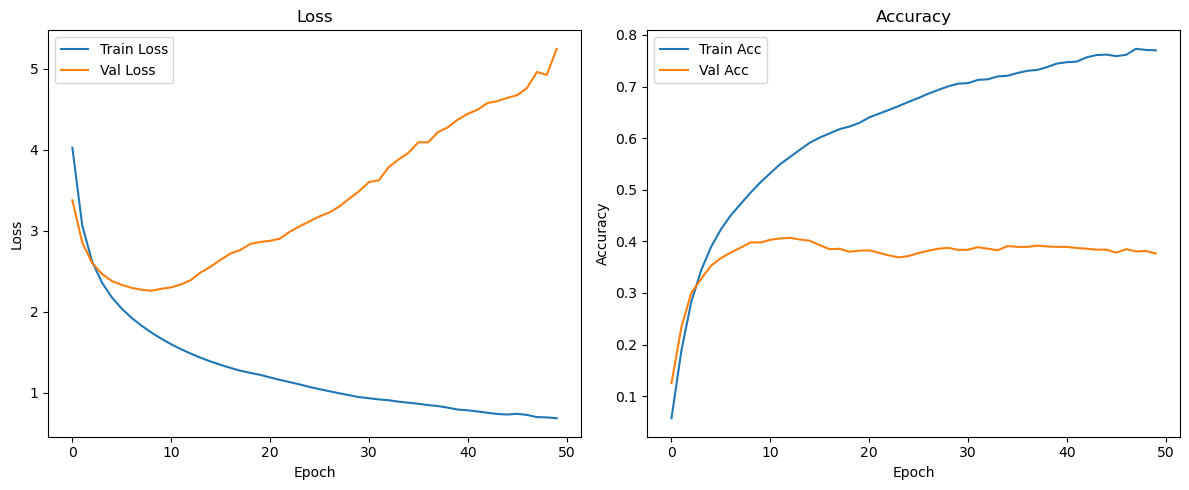

In [31]:
# Plot for LeNet model architecture
plot_metrics(lenet_train_losses, lenet_val_losses, lenet_train_accuracies, lenet_val_accuracies)

In [32]:
%load_ext tensorboard
%tensorboard --logdir runs